In [1]:
import pandas as pd
from sqlalchemy import create_engine
from geopy.distance import geodesic
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# file path of the raw dataset
path = 'C:\_Data_Analyst\_Projects_\Project_5\RawData.csv'

In [3]:
# Read CSV file into DataFrame
df = pd.read_csv(path)

In [4]:
# Dataset Validation Summary

DBTypes = df.dtypes
TotalCountDB = df.size
RowCount, ColCount = df.shape
CountOfUnique = df.nunique().sum()
CountOfNull = df.isnull().sum().sum()
NullPercentage = (CountOfNull/TotalCountDB)*100

In [5]:
print(f"""
========================================================
              DATASET VALIDATION SUMMARY
========================================================

Data Types                :
{DBTypes}

Total Count               : {TotalCountDB}
Row Count                 : {RowCount}
Column Count              : {ColCount}
Total Unique Count        : {CountOfUnique}
Total Null Count          : {CountOfNull}
Null Percentage           : {NullPercentage:.2f}%

========================================================
""")


              DATASET VALIDATION SUMMARY

Data Types                :
Order_ID            object
Agent_Age            int64
Agent_Rating       float64
Store_Latitude     float64
Store_Longitude    float64
Drop_Latitude      float64
Drop_Longitude     float64
Order_Date          object
Order_Time          object
Pickup_Time         object
Weather             object
Traffic             object
Vehicle             object
Area                object
Delivery_Time        int64
Category            object
dtype: object

Total Count               : 699824
Row Count                 : 43739
Column Count              : 16
Total Unique Count        : 53997
Total Null Count          : 145
Null Percentage           : 0.02%




In [6]:
# Remove Null Values and Duplicate Records

# Remove Rows with Null Values
df = df.dropna().copy()
Null_Count_After_Drop = df.isnull().sum()

# Remove Duplicate Records
DupesBeforeRemoval = df.duplicated().sum()
df = df.drop_duplicates().copy()
DupesRemoved = DupesBeforeRemoval - df.duplicated().sum()

In [7]:
print(f"""
========================================================
       NULL & DUPLICATE VALUE VALIDATION
========================================================

NULL VALUE VALIDATION AFTER REMOVAL
----------------------------------------
Null Count After Drop:
{Null_Count_After_Drop}

DUPLICATE RECORD VALIDATION
----------------------------------------
Duplicates Found   : {DupesBeforeRemoval}
Duplicates Removed : {DupesRemoved}

========================================================
""")


       NULL & DUPLICATE VALUE VALIDATION

NULL VALUE VALIDATION AFTER REMOVAL
----------------------------------------
Null Count After Drop:
Order_ID           0
Agent_Age          0
Agent_Rating       0
Store_Latitude     0
Store_Longitude    0
Drop_Latitude      0
Drop_Longitude     0
Order_Date         0
Order_Time         0
Pickup_Time        0
Weather            0
Traffic            0
Vehicle            0
Area               0
Delivery_Time      0
Category           0
dtype: int64

DUPLICATE RECORD VALIDATION
----------------------------------------
Duplicates Found   : 0
Duplicates Removed : 0




In [8]:
# Trim Leading and Trailing Spaces from Text Columns
str_cols = df.select_dtypes(include='object').columns

for col in str_cols:
    before = df[col].nunique()
    
    df[col] = df[col].str.strip()
    
    after = df[col].nunique()
    
    if before != after:
        print(f"{col}: {before} -> {after} unique values after trimming")

print(f"\nTrimmed {len(str_cols)} text columns: {list(str_cols)}")


Trimmed 9 text columns: ['Order_ID', 'Order_Date', 'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area', 'Category']


In [9]:
# Validate Dataset After Cleaning

TotalCount_AfterCleaning = df.size
RowCount_AfterCleaning, ColCount_AfterCleaning = df.shape
CountOfUnique_AfterCleaning = df.nunique().sum()
CountOfNull_AfterCleaning = df.isnull().sum().sum()
NullPercentage_AfterCleaning = (CountOfNull_AfterCleaning / TotalCount_AfterCleaning) * 100

In [10]:
print(f"""
========================================================
        DATASET VALIDATION SUMMARY AFTER CLEANING
========================================================

Total Count       : {TotalCount_AfterCleaning}
Row Count         : {RowCount_AfterCleaning}
Column Count      : {ColCount_AfterCleaning}
Total Unique      : {CountOfUnique_AfterCleaning}
Total Null Count  : {CountOfNull_AfterCleaning}
Null Percentage   : {NullPercentage_AfterCleaning:.2f}%

========================================================
""")


        DATASET VALIDATION SUMMARY AFTER CLEANING

Total Count       : 697504
Row Count         : 43594
Column Count      : 16
Total Unique      : 53783
Total Null Count  : 0
Null Percentage   : 0.00%




In [11]:
# Validate Latitude and Longitude Ranges

print("Latitude and Longitude Range Validation:")

for col in ['Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude']:
    print(f"{col}: Min = {df[col].min()}, Max = {df[col].max()}")

Latitude and Longitude Range Validation:
Store_Latitude: Min = -30.902872, Max = 30.914057
Store_Longitude: Min = 0.0, Max = 88.433452
Drop_Latitude: Min = 0.01, Max = 31.054057
Drop_Longitude: Min = 0.01, Max = 88.563452


In [12]:
# Check Negative Latitude and Longitude Values
neg_lat = df[df['Store_Latitude'] < 0]
neg_lon = df[df['Store_Longitude'] < 0]

print(f"""
========================================================
       NEGATIVE LATITUDE & LONGITUDE VALIDATION
========================================================

Negative Latitudes  : {len(neg_lat)}
Negative Longitudes : {len(neg_lon)}

Negative Latitude Records:
{neg_lat[['Store_Latitude', 'Store_Longitude']].head()}

========================================================
""")


       NEGATIVE LATITUDE & LONGITUDE VALIDATION

Negative Latitudes  : 151
Negative Longitudes : 0

Negative Latitude Records:
      Store_Latitude  Store_Longitude
90        -27.163303        78.057044
275       -27.165108        78.015053
1045      -15.546594        73.760431
1705      -23.230791        77.437020
1893      -22.539129        88.365507




In [13]:
# # Visualize Store Locations After Coordinate Correction

# plt.scatter(df['Store_Longitude'].abs(), df['Store_Latitude'].abs(), s=2)
# plt.xlabel('Longitude'); plt.ylabel('Latitude')
# plt.title('Store locations (abs applied)')
# plt.show()

In [14]:
# Check and Correct Negative Coordinate Values

neg_counts = {
    col: (df[col] < 0).sum()
    for col in ['Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude']
}

print(f"""
========================================================
       NEGATIVE COORDINATE VALUES BEFORE CORRECTION
========================================================

Negative Values:
{neg_counts}

========================================================
""")

for col in ['Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude']:
    df[col] = df[col].abs()

print("""
Negative latitude and longitude values corrected using
absolute values.
""")


       NEGATIVE COORDINATE VALUES BEFORE CORRECTION

Negative Values:
{'Store_Latitude': np.int64(151), 'Store_Longitude': np.int64(0), 'Drop_Latitude': np.int64(0), 'Drop_Longitude': np.int64(0)}



Negative latitude and longitude values corrected using
absolute values.



In [15]:
# Check Near-Zero Coordinate Values

near_zero = df[(df['Store_Longitude'].abs() < 0.5) | (df['Store_Latitude'].abs() < 0.5)]
print(f"Rows with near-zero coordinates: {len(near_zero)}")
print(near_zero[['Store_Latitude','Store_Longitude','Drop_Latitude','Drop_Longitude']])

Rows with near-zero coordinates: 3485
       Store_Latitude  Store_Longitude  Drop_Latitude  Drop_Longitude
33                0.0              0.0           0.11            0.11
51                0.0              0.0           0.03            0.03
56                0.0              0.0           0.08            0.08
58                0.0              0.0           0.06            0.06
66                0.0              0.0           0.02            0.02
...               ...              ...            ...             ...
43715             0.0              0.0           0.07            0.07
43722             0.0              0.0           0.13            0.13
43723             0.0              0.0           0.09            0.09
43725             0.0              0.0           0.05            0.05
43735             0.0              0.0           0.07            0.07

[3485 rows x 4 columns]


In [16]:
# Check Zero Coordinate Values
zero_coords = df[(df['Store_Latitude'] == 0) | (df['Store_Longitude'] == 0) |
                  (df['Drop_Latitude'] == 0) | (df['Drop_Longitude'] == 0)]
print(f"Rows with 0.0 coordinates: {len(zero_coords)}")

Rows with 0.0 coordinates: 3485


In [17]:
# Remove Invalid Near-Zero Coordinates
bad_geo = (df['Store_Latitude'].abs() < 0.5) | (df['Store_Longitude'].abs() < 0.5) | \
          (df['Drop_Latitude'].abs() < 0.5) | (df['Drop_Longitude'].abs() < 0.5)
print(f"Dropping {bad_geo.sum()} rows with invalid (near-zero) coordinates")
df = df[~bad_geo].copy()

Dropping 3485 rows with invalid (near-zero) coordinates


In [18]:
 # df.loc[bad_geo, ['Distance_km', 'Speed_kmph']] = pd.NA

In [19]:
print(f"""
========================================================
          INVALID COORDINATE REMOVAL SUMMARY
========================================================

Rows Dropped     : {bad_geo.sum()}
Rows Remaining   : {len(df)}

========================================================
""")


          INVALID COORDINATE REMOVAL SUMMARY

Rows Dropped     : 3485
Rows Remaining   : 40109




In [20]:
# Validate Coordinate Ranges After Correction
print(f"""
========================================================
          COORDINATE RANGE VALIDATION
========================================================

""")

for col in ['Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude']:
    print(f"{col}: Min = {df[col].min():.6f}, Max = {df[col].max():.6f}")

print("""
========================================================
""")


          COORDINATE RANGE VALIDATION


Store_Latitude: Min = 9.957144, Max = 30.914057
Store_Longitude: Min = 72.768726, Max = 88.433452
Drop_Latitude: Min = 9.967144, Max = 31.054057
Drop_Longitude: Min = 72.778726, Max = 88.563452




In [21]:
# Convert Order Date to Datetime
df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    format='%d-%m-%Y'
)

In [22]:
# Create Date and Demographic Helper Columns

df['Month'] = df['Order_Date'].dt.month_name()
df['Month_Number'] = df['Order_Date'].dt.month
df['Day_of_Week'] = df['Order_Date'].dt.day_name()
df['Order_Hour'] = pd.to_timedelta(df['Order_Time'].astype(str)).dt.components['hours']
df['Age_Group'] = pd.cut(df['Agent_Age'], bins=[18,25,30,35,40,50,100], labels=['18-25','26-30','31-35','36-40','41-50','50+'])

In [23]:
print(f"""
========================================================
           HELPER COLUMNS CREATED
========================================================

Month              : {df['Month'].unique()}
Month Number       : {df['Month_Number'].unique()}
Day of Week        : {df['Day_of_Week'].unique()}
Order Hour Range   : {df['Order_Hour'].min()} - {df['Order_Hour'].max()}
Age Groups         : {df['Age_Group'].unique()}

========================================================
""")


           HELPER COLUMNS CREATED

Month              : ['March' 'April' 'February']
Month Number       : [3 4 2]
Day of Week        : ['Saturday' 'Friday' 'Tuesday' 'Monday' 'Sunday' 'Wednesday' 'Thursday']
Order Hour Range   : 0 - 23
Age Groups         : ['36-40', '31-35', '18-25', '26-30']
Categories (6, object): ['18-25' < '26-30' < '31-35' < '36-40' < '41-50' < '50+']




In [24]:
# Validate Order-to-Pickup Time and Midnight Rollover

df.loc[:, 'Order_to_Pickup_Minutes'] = (
    pd.to_timedelta(df['Pickup_Time'].astype(str)) -
    pd.to_timedelta(df['Order_Time'].astype(str))
).dt.total_seconds() / 60

# Fix midnight rollover: if negative, add a full day
df.loc[df['Order_to_Pickup_Minutes'] < 0, 'Order_to_Pickup_Minutes'] += 1440

# Check rows with suspiciously large values after correction
rollover_count = (df['Order_to_Pickup_Minutes'] > 1000).sum()

In [25]:
print(f"""
========================================================
       ORDER-TO-PICKUP TIME VALIDATION
========================================================

Rows with Implausibly Large Values : {rollover_count}

Order-to-Pickup Time Statistics:
{df['Order_to_Pickup_Minutes'].describe()}

========================================================
""")


       ORDER-TO-PICKUP TIME VALIDATION

Rows with Implausibly Large Values : 0

Order-to-Pickup Time Statistics:
count    40109.000000
mean         9.980802
std          4.086202
min          5.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: Order_to_Pickup_Minutes, dtype: float64




In [26]:
# Calculate Distance Between Store and Drop Locations
df['Distance_km'] = round(df.apply(
    lambda row: geodesic(
        (row['Store_Latitude'], row['Store_Longitude']),
        (row['Drop_Latitude'], row['Drop_Longitude'])
    ).km,
    axis=1
))
df['Distance_Bucket'] = pd.cut(df['Distance_km'], bins=[0, 2, 5, 10, 20, 50], labels=['0-2km', '2-5km', '5-10km', '10-20km', '20km+'])

In [27]:
# Calculate Delivery Speed

print("Zero delivery times:", (df['Delivery_Time'] == 0).sum())

df['Speed_kmph'] = df['Distance_km'] / (df['Delivery_Time'] / 60)
df['Speed_kmph'] = df['Speed_kmph'].replace([float('inf'), -float('inf')], pd.NA)

Zero delivery times: 0


In [28]:
# Calculate On-Time Delivery Based on Median SLA

SLA_TARGET = df['Delivery_Time'].median()
df['On_Time'] = df['Delivery_Time'] <= SLA_TARGET
OnTimeDelivery  = df['On_Time'].mean() * 100

In [29]:
print(f"""
========================================================
              ON-TIME DELIVERY ANALYSIS
========================================================

SLA Target (Median Delivery Time) : {SLA_TARGET:.0f} minutes
On-Time Delivery                  : {OnTimeDelivery:.2f}%

========================================================
""")


              ON-TIME DELIVERY ANALYSIS

SLA Target (Median Delivery Time) : 125 minutes
On-Time Delivery                  : 52.87%




In [30]:
# Age Group vs Delivery Performance Analysis

AgeVsPerformance = df.groupby('Age_Group', observed=True).agg(
    Avg_Delivery_Time=('Delivery_Time', 'mean'),
    Avg_Speed_kmph=('Speed_kmph', 'mean'),
    On_Time_Rate=('On_Time', 'mean'),
    On_Time_Orders=('On_Time', 'sum'),
    Order_Count=('Order_ID', 'count')
)
AgeVsPerformance['On_Time_Rate'] = AgeVsPerformance['On_Time_Rate'] * 100

In [31]:
print(f"""
========================================================
             AGE GROUP VS PERFORMANCE
========================================================

{AgeVsPerformance}

========================================================
""")


             AGE GROUP VS PERFORMANCE

           Avg_Delivery_Time  Avg_Speed_kmph  On_Time_Rate  On_Time_Orders  \
Age_Group                                                                    
18-25             109.265827        6.825961     67.573468            8048   
26-30             115.431122        6.517915     62.284289            6244   
31-35             141.162323        5.085929     37.666600            3787   
36-40             140.305542        4.990456     38.497537            3126   

           Order_Count  
Age_Group               
18-25            11910  
26-30            10025  
31-35            10054  
36-40             8120  




In [32]:
# Correlation Analysis of Delivery Performance

corr_cols = ['Agent_Rating', 'Delivery_Time', 'Speed_kmph', 'Distance_km']
Correlation_Matrix = df[corr_cols].corr()
print(f"""
========================================================
           DELIVERY PERFORMANCE CORRELATION
========================================================

Correlation Matrix:
{Correlation_Matrix.round(2)}

========================================================
""")


           DELIVERY PERFORMANCE CORRELATION

Correlation Matrix:
               Agent_Rating  Delivery_Time  Speed_kmph  Distance_km
Agent_Rating           1.00          -0.31        0.07        -0.11
Delivery_Time         -0.31           1.00       -0.46         0.28
Speed_kmph             0.07          -0.46        1.00         0.43
Distance_km           -0.11           0.28        0.43         1.00




In [33]:
# Agent Rating Analysis by Traffic, Weather, Vehicle, Age Group and On-Time Status

RatingByTraffic = df.groupby('Traffic')['Agent_Rating'].mean().sort_values(ascending=False)
RatingByWeather = df.groupby('Weather')['Agent_Rating'].mean().sort_values(ascending=False)
RatingByVehicle = df.groupby('Vehicle')['Agent_Rating'].mean().sort_values(ascending=False)
RatingByAgeGroup = df.groupby('Age_Group', observed=True)['Agent_Rating'].mean()
RatingByOnTime = df.groupby('On_Time')['Agent_Rating'].mean()

In [34]:
print(f"""
========================================================
              AGENT RATING ANALYSIS
========================================================

Rating by Traffic:
{RatingByTraffic.round(2)}

Rating by Weather:
{RatingByWeather.round(2)}

Rating by Vehicle:
{RatingByVehicle.round(2)}

Rating by Age Group:
{RatingByAgeGroup.round(2)}

Rating by On-Time Status:
{RatingByOnTime.round(2)}

========================================================
""")


              AGENT RATING ANALYSIS

Rating by Traffic:
Traffic
Medium    4.66
High      4.66
Low       4.65
Jam       4.59
Name: Agent_Rating, dtype: float64

Rating by Weather:
Weather
Sunny         4.66
Fog           4.65
Cloudy        4.65
Windy         4.62
Stormy        4.61
Sandstorms    4.61
Name: Agent_Rating, dtype: float64

Rating by Vehicle:
Vehicle
van           4.65
scooter       4.64
motorcycle    4.63
Name: Agent_Rating, dtype: float64

Rating by Age Group:
Age_Group
18-25    4.68
26-30    4.66
31-35    4.59
36-40    4.59
Name: Agent_Rating, dtype: float64

Rating by On-Time Status:
On_Time
False    4.54
True     4.72
Name: Agent_Rating, dtype: float64




In [35]:
Order_HourSummary = df.groupby('Order_Hour').agg(
    Total_Orders=('Order_ID', 'nunique'),
    On_Time_Orders=('On_Time', 'sum'),
    On_Time_Rate=('On_Time', 'mean'),
    Avg_Delivery_Time=('Delivery_Time', 'mean'),
    Avg_Speed_kmph=('Speed_kmph', 'mean')
)
Order_HourSummary['On_Time_Rate']=Order_HourSummary['On_Time_Rate']*100

In [36]:
print(f"""
===========================
      Order_Hour SUMMARY
============================

{Order_HourSummary.round(2)}

============================
""")


      Order_Hour SUMMARY

            Total_Orders  On_Time_Orders  On_Time_Rate  Avg_Delivery_Time  \
Order_Hour                                                                  
0                    395             285         72.15             102.86   
8                   1668            1388         83.21              93.10   
9                   1779            1488         83.64              92.59   
10                  1811            1517         83.77              93.08   
11                  1793             867         48.35             125.77   
12                   821             368         44.82             129.18   
13                   715             304         42.52             131.78   
14                   717             310         43.24             129.53   
15                   798             486         60.90             109.80   
16                   646             386         59.75             109.64   
17                  3909            1765         

In [37]:
# Day-wise Delivery Performance Analysis

WeekSummary = df.groupby('Day_of_Week').agg(
    Avg_Delivery_Time=('Delivery_Time', 'mean'),
    Avg_Speed_kmph=('Speed_kmph', 'mean'),
    Total_Orders=('Order_ID', 'nunique'),
    On_Time_Orders=('On_Time', 'sum'),
    On_Time_Rate=('On_Time', 'mean')
).reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

WeekSummary['On_Time_Rate'] = WeekSummary['On_Time_Rate'] * 100

In [38]:
print(f"""
========================================================
          DAY-WISE DELIVERY PERFORMANCE
========================================================

{WeekSummary.round(2)}

========================================================
""")


          DAY-WISE DELIVERY PERFORMANCE

             Avg_Delivery_Time  Avg_Speed_kmph  Total_Orders  On_Time_Orders  \
Day_of_Week                                                                    
Monday                  124.66            5.80          5470            2941   
Tuesday                 120.88            5.25          5603            3092   
Wednesday               131.80            7.00          6261            3001   
Thursday                120.41            5.31          5596            3140   
Friday                  127.02            6.36          6129            3153   
Saturday                124.51            5.73          5561            2945   
Sunday                  125.33            5.97          5489            2933   

             On_Time_Rate  
Day_of_Week                
Monday              53.77  
Tuesday             55.18  
Wednesday           47.93  
Thursday            56.11  
Friday              51.44  
Saturday            52.96  
Sunday       

In [39]:
# Month-wise Delivery Performance Analysis
MonthSummary = df.groupby(['Month', 'Month_Number']).agg(
    Avg_Delivery_Time=('Delivery_Time', 'mean'),
    Avg_Speed_kmph=('Speed_kmph', 'mean'),
    Total_Orders=('Order_ID', 'nunique'),
    On_Time_Orders=('On_Time', 'sum'),
    On_Time_Rate=('On_Time', 'mean')
).sort_values('Month_Number')

MonthSummary['On_Time_Rate'] = MonthSummary['On_Time_Rate'] * 100

In [40]:
print(f"""
========================================================
          MONTH-WISE DELIVERY PERFORMANCE
========================================================

{MonthSummary.round(2)}

========================================================
""")


          MONTH-WISE DELIVERY PERFORMANCE

                       Avg_Delivery_Time  Avg_Speed_kmph  Total_Orders  \
Month    Month_Number                                                    
February 2                        126.54            5.82          5737   
March    3                        124.95            5.97         28659   
April    4                        124.28            5.93          5713   

                       On_Time_Orders  On_Time_Rate  
Month    Month_Number                                
February 2                       2939         51.23  
March    3                      15164         52.91  
April    4                       3102         54.30  




In [41]:
# Distance Bucket Analysis
OrderDistance_Bucket = df.groupby('Distance_Bucket', observed=True)['Order_ID'].nunique()
OrderOnTimeDistance_Bucket = df.groupby(['Distance_Bucket','On_Time'], observed=True)['Order_ID'].nunique()
Distance_kmvsDistance_Bucket = df.groupby('Distance_Bucket', observed=True)['Distance_km'].mean()
Speed_kmphvsDistance_Bucket = df.groupby('Distance_Bucket', observed=True)['Speed_kmph'].mean()
OnTimeRateByDistance = df.groupby('Distance_Bucket', observed=True)['On_Time'].mean() * 100

In [42]:
print(f"""
========================================================
              DISTANCE BUCKET ANALYSIS
========================================================

Orders by Distance Bucket:
{OrderDistance_Bucket}

On-Time Orders by Distance Bucket:
{OrderOnTimeDistance_Bucket}

Average Distance by Bucket:
{Distance_kmvsDistance_Bucket.round(2)}

Average Speed by Distance Bucket:
{Speed_kmphvsDistance_Bucket.round(2)}

On-Time Rate by Distance Bucket:
{OnTimeRateByDistance.round(2)}%

========================================================
""")


              DISTANCE BUCKET ANALYSIS

Orders by Distance Bucket:
Distance_Bucket
0-2km       3625
2-5km       7177
5-10km     11318
10-20km    17524
20km+        465
Name: Order_ID, dtype: int64

On-Time Orders by Distance Bucket:
Distance_Bucket  On_Time
0-2km            False        941
                 True        2684
2-5km            False       2365
                 True        4812
5-10km           False       4926
                 True        6392
10-20km          False      10394
                 True        7130
20km+            False        278
                 True         187
Name: Order_ID, dtype: int64

Average Distance by Bucket:
Distance_Bucket
0-2km       1.86
2-5km       3.93
5-10km      7.73
10-20km    14.82
20km+      21.00
Name: Distance_km, dtype: float64

Average Speed by Distance Bucket:
Distance_Bucket
0-2km       1.42
2-5km       2.89
5-10km      5.35
10-20km     8.35
20km+      11.74
Name: Speed_kmph, dtype: float64

On-Time Rate by Distance Bucket:
Dista

In [43]:
# Speed Analysis by Distance Bucket and Operating Conditions
SpeedByDistanceVehicle = df.groupby(['Distance_Bucket', 'Vehicle'], observed=True)['Speed_kmph'].mean().unstack()
SpeedByDistanceWeather = df.groupby(['Distance_Bucket', 'Weather'], observed=True)['Speed_kmph'].mean().unstack()
SpeedByDistanceTraffic = df.groupby(['Distance_Bucket', 'Traffic'], observed=True)['Speed_kmph'].mean().unstack()
SpeedByDistanceArea = df.groupby(['Distance_Bucket', 'Area'], observed=True)['Speed_kmph'].mean().unstack()

In [44]:
print(f"""
========================================================
       SPEED BY DISTANCE & OPERATING CONDITIONS
========================================================

Speed by Distance Bucket & Vehicle:
{SpeedByDistanceVehicle.round(2)}

Speed by Distance Bucket & Weather:
{SpeedByDistanceWeather.round(2)}

Speed by Distance Bucket & Traffic:
{SpeedByDistanceTraffic.round(2)}

Speed by Distance Bucket & Area:
{SpeedByDistanceArea.round(2)}

========================================================
""")


       SPEED BY DISTANCE & OPERATING CONDITIONS

Speed by Distance Bucket & Vehicle:
Vehicle          motorcycle  scooter    van
Distance_Bucket                            
0-2km                  1.36     1.49   1.59
2-5km                  2.67     3.19   3.20
5-10km                 5.06     5.78   5.78
10-20km                7.96     8.90   8.87
20km+                 11.52    11.71  13.37

Speed by Distance Bucket & Weather:
Weather          Cloudy   Fog  Sandstorms  Stormy  Sunny  Windy
Distance_Bucket                                                
0-2km              1.43  1.54        1.40    1.30   1.56   1.32
2-5km              2.95  2.96        2.80    2.78   3.25   2.59
5-10km             5.13  5.39        5.00    4.95   6.63   5.04
10-20km            6.23  6.64        9.03    8.95  10.33   9.08
20km+              8.10  9.57       13.09   13.67  14.14  12.46

Speed by Distance Bucket & Traffic:
Traffic          High    Jam    Low  Medium
Distance_Bucket                         

In [45]:
# Weather-wise Delivery Performance Summary

WeatherSummary = df.groupby('Weather').agg(
        Avg_Delivery_Time=('Delivery_Time', 'mean'),
    Avg_Speed_kmph=('Speed_kmph', 'mean'),
    OrdersWeather = ('Order_ID', 'count'),
    onTimeWeather = ('On_Time', 'sum'),
    onTimeRateWeather = ('On_Time','mean')
).sort_values('OrdersWeather', ascending=False)
WeatherSummary['onTimeRateWeather'] = WeatherSummary['onTimeRateWeather'] * 100

In [46]:
print(f"""
========================================================
          WEATHER-WISE DELIVERY PERFORMANCE
========================================================

{WeatherSummary.round(2)}

========================================================
""")


          WEATHER-WISE DELIVERY PERFORMANCE

            Avg_Delivery_Time  Avg_Speed_kmph  OrdersWeather  onTimeWeather  \
Weather                                                                       
Fog                    136.93            5.22           6805           2964   
Stormy                 123.43            6.09           6773           3554   
Cloudy                 138.35            4.93           6693           2824   
Sandstorms             123.28            6.10           6676           3525   
Windy                  123.93            6.12           6638           3391   
Sunny                  103.88            7.22           6524           4947   

            onTimeRateWeather  
Weather                        
Fog                     43.56  
Stormy                  52.47  
Cloudy                  42.19  
Sandstorms              52.80  
Windy                   51.08  
Sunny                   75.83  




In [47]:
# Traffic-wise Delivery Performance Analysis

TrafficSummary = df.groupby('Traffic').agg(
    Total_Orders=('Order_ID', 'nunique'),
    On_Time_Orders=('On_Time', 'sum'),
    On_Time_Rate=('On_Time', 'mean'),
    Avg_Delivery_Time=('Delivery_Time', 'mean'),
    Avg_Speed_kmph=('Speed_kmph', 'mean')
).sort_values('Avg_Delivery_Time')

TrafficSummary['On_Time_Rate'] = TrafficSummary['On_Time_Rate'] * 100

In [48]:
print(f"""
========================================================
          TRAFFIC-WISE DELIVERY PERFORMANCE
========================================================

{TrafficSummary.round(2)}

========================================================
""")


          TRAFFIC-WISE DELIVERY PERFORMANCE

         Total_Orders  On_Time_Orders  On_Time_Rate  Avg_Delivery_Time  \
Traffic                                                                  
Low             13739           10452         76.08             101.44   
Medium           9774            4701         48.10             126.97   
High             3949            1743         44.14             129.52   
Jam             12647            4309         34.07             147.93   

         Avg_Speed_kmph  
Traffic                  
Low                5.98  
Medium             6.63  
High               2.68  
Jam                6.38  




In [49]:
# Vehicle-wise Delivery Performance Analysis

VehicleSummary = df.groupby('Vehicle').agg(
    Total_Orders=('Order_ID', 'nunique'),
    On_Time_Orders=('On_Time', 'sum'),
    On_Time_Rate=('On_Time', 'mean'),
    Avg_Delivery_Time=('Delivery_Time', 'mean'),
    Avg_Speed_kmph=('Speed_kmph', 'mean')
).sort_values('Avg_Delivery_Time')

VehicleSummary['On_Time_Rate'] = VehicleSummary['On_Time_Rate'] * 100

In [50]:
print(f"""
========================================================
          VEHICLE-WISE DELIVERY PERFORMANCE
========================================================

{VehicleSummary.round(2)}

========================================================
""")


          VEHICLE-WISE DELIVERY PERFORMANCE

            Total_Orders  On_Time_Orders  On_Time_Rate  Avg_Delivery_Time  \
Vehicle                                                                     
van                 3190            1864         58.43             116.08   
scooter            13389            7834         58.51             116.62   
motorcycle         23530           11507         48.90             131.12   

            Avg_Speed_kmph  
Vehicle                     
van                   6.40  
scooter               6.37  
motorcycle            5.64  




In [51]:
# Area-wise Order and On-Time Delivery Analysis

AreaSummary = df.groupby('Area').agg(
    Avg_Delivery_Time=('Delivery_Time', 'mean'),
    Avg_Speed_kmph=('Speed_kmph', 'mean'),
    Total_Orders=('Order_ID', 'nunique'),
    On_Time_Orders=('On_Time', 'sum'),
    On_Time_Rate=('On_Time', 'mean')
).sort_values('Total_Orders', ascending=False)
AreaSummary['On_Time_Rate'] = AreaSummary['On_Time_Rate'] * 100

In [52]:
print(f"""
========================================================
             AREA-WISE DELIVERY SUMMARY
========================================================

{AreaSummary.round(2)}

========================================================
""")


             AREA-WISE DELIVERY SUMMARY

               Avg_Delivery_Time  Avg_Speed_kmph  Total_Orders  \
Area                                                             
Metropolitian             129.85            5.77         30030   
Urban                     109.67            6.43          8891   
Other                     104.52            6.97          1050   
Semi-Urban                238.72            3.86           138   

               On_Time_Orders  On_Time_Rate  
Area                                         
Metropolitian           14556         48.47  
Urban                    5903         66.39  
Other                     739         70.38  
Semi-Urban                  7          5.07  




In [53]:
# Distance Bucket-wise Delivery Performance Analysis

Distance_BucketSummary = df.groupby('Distance_Bucket', observed=True).agg(
    Avg_Delivery_Time=('Delivery_Time', 'mean'),
    Avg_Speed_kmph=('Speed_kmph', 'mean'),
    Total_Orders=('Order_ID', 'nunique'),
    On_Time_Orders=('On_Time', 'sum'),
    On_Time_Rate=('On_Time', 'mean')
)

Distance_BucketSummary['On_Time_Rate'] = (
    Distance_BucketSummary['On_Time_Rate'] * 100
)

In [54]:
print(f"""
========================================================
       DISTANCE BUCKET DELIVERY PERFORMANCE
========================================================

{Distance_BucketSummary.round(2)}

========================================================
""")


       DISTANCE BUCKET DELIVERY PERFORMANCE

                 Avg_Delivery_Time  Avg_Speed_kmph  Total_Orders  \
Distance_Bucket                                                    
0-2km                       102.10            1.42          3625   
2-5km                       107.32            2.89          7177   
5-10km                      116.76            5.35         11318   
10-20km                     142.03            8.35         17524   
20km+                       142.48           11.74           465   

                 On_Time_Orders  On_Time_Rate  
Distance_Bucket                                
0-2km                      2684         74.04  
2-5km                      4812         67.05  
5-10km                     6392         56.48  
10-20km                    7130         40.69  
20km+                       187         40.22  




In [55]:
# Key Performance Indicators (KPIs)

TotalOrders = df['Order_ID'].nunique()
AverageDeliveryTime = df['Delivery_Time'].mean()
AverageSpeed_kmph  = df['Speed_kmph'].mean()
AverageDistancePerOrder =  df['Distance_km'].mean()

In [56]:
print(f"""
========================================================
              DELIVERY PERFORMANCE KPIs
========================================================

Total Orders                  : {TotalOrders:,}
SLA Target                    : {SLA_TARGET:.2f} minutes
On-Time Delivery Rate         : {OnTimeDelivery:.2f}%
Average Delivery Time         : {AverageDeliveryTime:.2f} minutes
Average Speed                 : {AverageSpeed_kmph:.2f} km/h
Average Distance per Order    : {AverageDistancePerOrder:.2f} km

========================================================
""")


              DELIVERY PERFORMANCE KPIs

Total Orders                  : 40,109
SLA Target                    : 125.00 minutes
On-Time Delivery Rate         : 52.87%
Average Delivery Time         : 125.09 minutes
Average Speed                 : 5.94 km/h
Average Distance per Order    : 9.77 km




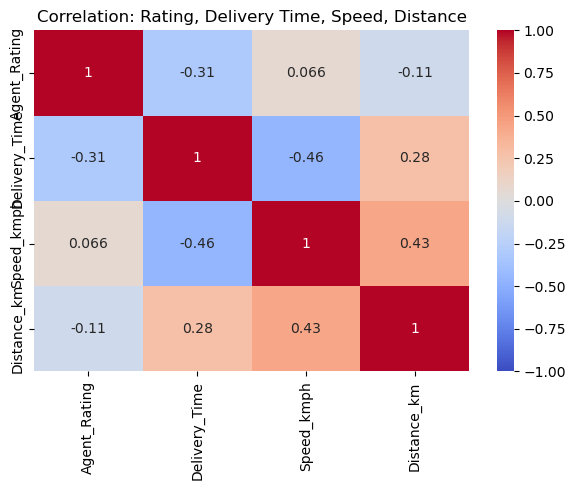

In [57]:
plt.figure(figsize=(6,5))
sns.heatmap(Correlation_Matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation: Rating, Delivery Time, Speed, Distance')
plt.tight_layout()
plt.show()

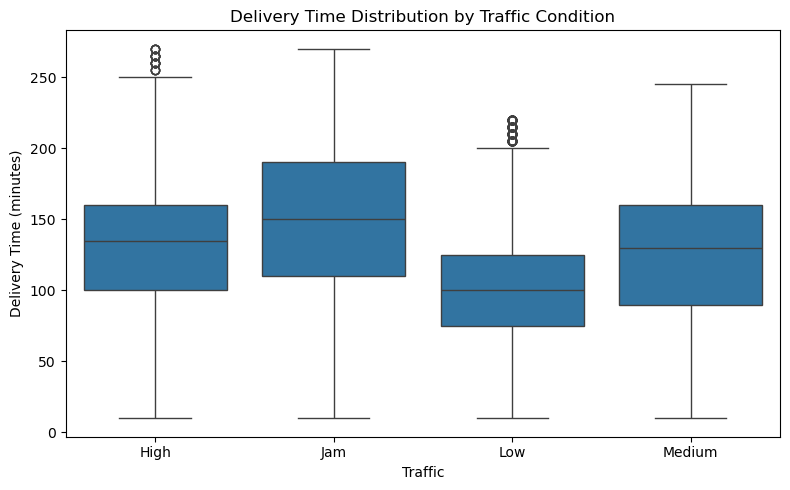

In [58]:
# Boxplot — Delivery Time by Traffic
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Traffic', y='Delivery_Time')
plt.title('Delivery Time Distribution by Traffic Condition')
plt.xlabel('Traffic')
plt.ylabel('Delivery Time (minutes)')
plt.tight_layout()
plt.show()

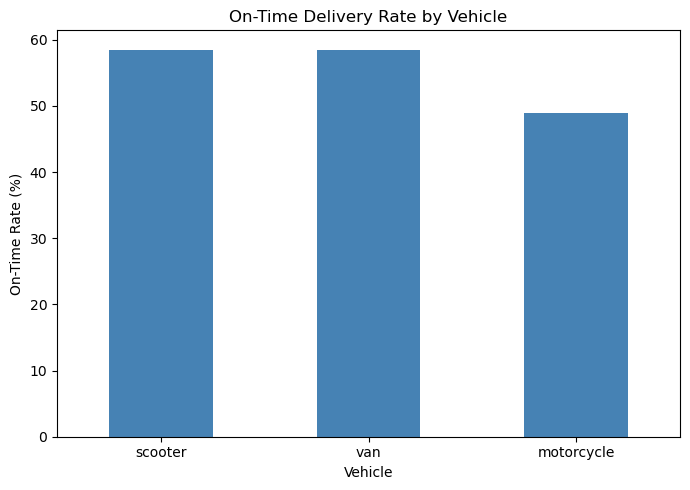

In [59]:
# Bar chart — On-Time Rate by Vehicle
plt.figure(figsize=(7,5))
VehicleSummary['On_Time_Rate'].sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('On-Time Delivery Rate by Vehicle')
plt.ylabel('On-Time Rate (%)')
plt.xlabel('Vehicle')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

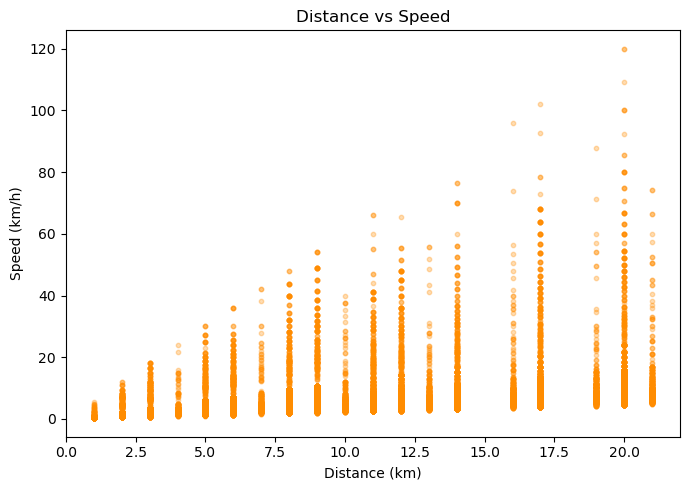

In [60]:
# Scatter — Distance vs Speed
plt.figure(figsize=(7,5))
plt.scatter(df['Distance_km'], df['Speed_kmph'], alpha=0.3, s=10, color='darkorange')
plt.xlabel('Distance (km)')
plt.ylabel('Speed (km/h)')
plt.title('Distance vs Speed')
plt.tight_layout()
plt.show()

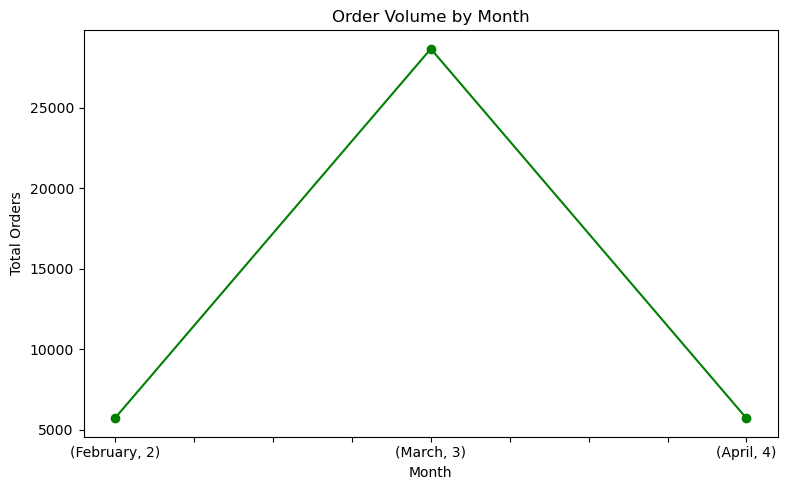

In [61]:
# Line chart — Orders by Month (trend over time)

plt.figure(figsize=(8,5))
MonthSummary['Total_Orders'].plot(kind='line', marker='o', color='green')
plt.title('Order Volume by Month')
plt.ylabel('Total Orders')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

In [62]:
# # Database Configuration
USER = 'root'
HOST = '127.0.0.1'
PORT = '3306'
DataBase = 'delivery_data'
Table_Name = 'delivery_data_table'

In [63]:
# Export Dataset to MySQL
engine = None
try:
    engine = create_engine(f"mysql+pymysql://{USER}@{HOST}:{PORT}/{DataBase}")
    df.to_sql(
        Table_Name,
        engine,
        if_exists = 'replace',
        index = False,
        chunksize = 10000
    )
    
    print(f"'{Table_Name}' loaded successfully into '{DataBase}' database.")
    
except Exception as e:
    print("Failed to load data into MySQL")
    print(f"Error : {e}")
finally:
    if engine:
        engine.dispose()
        print("Data Connection Close")

'delivery_data_table' loaded successfully into 'delivery_data' database.
Data Connection Close


In [64]:
Column_Count = df.shape[0]

In [65]:
df['On_Time'].count()

np.int64(40109)

In [66]:
df[df['On_Time'] == True]['On_Time'].count()

np.int64(21205)